# Proyecto Kaggle: Retención de clientes para una entidad financiera

- **UIMP - Máster Universitario en Investigación en Inteligencia Artificial**  
- **Ciencia de Datos y Aprendizaje Automático**

---

## Objetivo

Predecir qué clientes van a abandonar el banco (`Exited=1`) y cuáles se quedan (`Exited=0`), optimizando el **recall** (sensibilidad), que es la métrica de la competición Kaggle.

## Estructura del notebook

1. Importación de librerías
2. Carga de datos
3. EDA
4. Preparación de datos
5. Pipeline de preprocesamiento
6. Comparación de modelos
7. Tuning de hiperparámetros (XGBoost y LightGBM)
8. Ajuste de umbral
9. Generación de submissions


El trabajo quedó planteado como una secuencia bastante directa: primero comprobar si el desbalanceo y las variables más informativas justificaban un pipeline cuidadoso; después contrastar modelos con validación cruzada; y, por último, ver qué aguantaba mejor al pasar de CV a Kaggle. Las señales más claras del EDA fueron edad, actividad del cliente, saldo y geografía, y a partir de ahí construí las variables derivadas y la comparativa final.

## 1. Importación de librerías

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento
from sklearn.model_selection import (
    StratifiedKFold, cross_validate, RandomizedSearchCV, cross_val_predict
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Métricas
from sklearn.metrics import (
    recall_score, precision_score, f1_score
)

# Configuración de visualización
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['figure.dpi'] = 100

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


## 2. Carga de datos

In [2]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
test_ids = test['CustomerId'].copy()

print(f'Conjunto de entrenamiento: {train.shape[0]} instancias, {train.shape[1]} variables')
print(f'Conjunto de prueba:        {test.shape[0]} instancias, {test.shape[1]} variables')

Conjunto de entrenamiento: 8000 instancias, 13 variables
Conjunto de prueba:        2000 instancias, 12 variables


In [4]:
train.head(10)

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15759244,Boone,687.0,Germany,Male,44,8,95368.14,2.0,1.0,1,1787.85,0
1,15725997,She,660.0,France,Female,35,6,100768.77,1.0,1.0,0,19199.61,0
2,15724296,Kerr,684.0,Spain,Male,41,2,119782.72,2.0,0.0,0,120284.67,0
3,15636820,Loggia,725.0,Germany,Male,40,8,104149.66,1.0,1.0,0,62027.90,0
4,15744529,Chiekwugo,510.0,France,Male,63,8,0.00,2.0,1.0,1,115291.86,0
5,15763907,Watts,820.0,France,Female,39,1,104614.29,1.0,1.0,0,61538.43,1
6,15671800,Robinson,688.0,France,Male,20,8,137624.40,2.0,1.0,1,197582.79,0
7,15567383,Slone,678.0,Germany,Female,44,2,98009.13,2.0,0.0,1,31384.86,0
8,15777179,Ellis,NaN,France,Male,35,9,NaN,2.0,0.0,1,NaN,0
9,15650391,NaN,633.0,France,Female,29,7,169988.35,1.0,1.0,0,4272.00,0


In [3]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       8000 non-null   int64  
 1   Surname          7591 non-null   str    
 2   CreditScore      6359 non-null   float64
 3   Geography        8000 non-null   str    
 4   Gender           8000 non-null   str    
 5   Age              8000 non-null   int64  
 6   Tenure           8000 non-null   int64  
 7   Balance          6385 non-null   float64
 8   NumOfProducts    7024 non-null   float64
 9   HasCrCard        7625 non-null   float64
 10  IsActiveMember   8000 non-null   int64  
 11  EstimatedSalary  7168 non-null   float64
 12  Exited           8000 non-null   int64  
dtypes: float64(5), int64(5), str(3)
memory usage: 812.6 KB


In [4]:
train.describe().round(2)

,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,8000.00,6359.00,8000.00,8000.00,6385.00,7024.00,7625.00,8000.00,7168.00,8000.0
mean,15691188.45,661.24,38.94,5.01,76929.67,1.54,0.71,0.51,100057.17,0.2
std,71872.27,95.88,10.38,2.89,62292.13,0.57,0.46,0.50,57441.73,0.4
min,15565701.00,350.00,18.00,0.00,0.00,1.00,0.00,0.00,11.58,0.0
25%,15628959.75,595.00,32.00,3.00,0.00,1.00,0.00,0.00,51545.35,0.0
50%,15691115.00,664.00,37.00,5.00,98009.13,2.00,1.00,1.00,100129.08,0.0
75%,15753727.75,729.00,44.00,8.00,127660.46,2.00,1.00,1.00,149216.32,0.0
max,15815690.00,850.00,92.00,10.00,250898.09,4.00,1.00,1.00,199992.48,1.0


## 3. Análisis exploratorio de datos (EDA)

### 3.1 Variable objetivo

Permanecen (0): 6370 (79.6%)
Abandonan  (1): 1630 (20.4%)
Ratio desbalanceo: 3.91:1


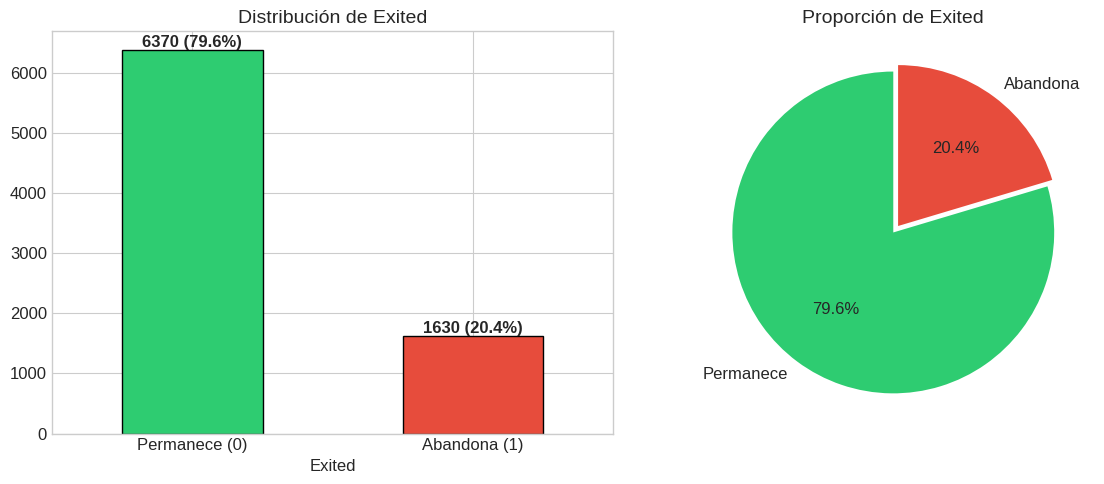

In [5]:
target_counts = train['Exited'].value_counts()
target_pct = train['Exited'].value_counts(normalize=True) * 100

print(f'Permanecen (0): {target_counts[0]} ({target_pct[0]:.1f}%)')
print(f'Abandonan  (1): {target_counts[1]} ({target_pct[1]:.1f}%)')
print(f'Ratio desbalanceo: {target_counts[0]/target_counts[1]:.2f}:1')

colors = ['#2ecc71', '#e74c3c']
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

target_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='black')
axes[0].set_title('Distribución de Exited', fontsize=14)
axes[0].set_xticklabels(['Permanece (0)', 'Abandona (1)'], rotation=0)
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 50, f'{v} ({target_pct.values[i]:.1f}%)', ha='center', fontweight='bold')

axes[1].pie(target_counts, labels=['Permanece', 'Abandona'], autopct='%1.1f%%',
            colors=colors, startangle=90, explode=(0, 0.05))
axes[1].set_title('Proporción de Exited', fontsize=14)

plt.tight_layout()
plt.show()

Hay un desbalanceo claro: casi 4 de cada 5 clientes pertenecen a la clase 0. Eso significa que un modelo trivial podría acertar mucho en accuracy diciendo siempre "permanece", pero sería inútil para la métrica del concurso.

### 3.2 Valores faltantes

                 Faltantes     %
CreditScore           1641  20.5
Balance               1615  20.2
NumOfProducts          976  12.2
EstimatedSalary        832  10.4
Surname                409   5.1
HasCrCard              375   4.7


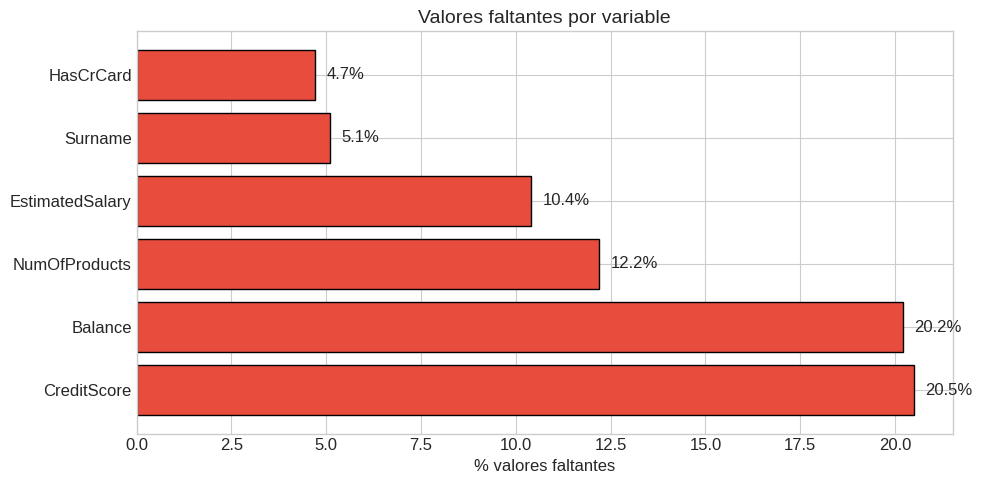

In [6]:
missing = train.isnull().sum()
missing_pct = (missing / len(train)) * 100
missing_df = pd.DataFrame({'Faltantes': missing, '%': missing_pct.round(1)}).query('Faltantes > 0').sort_values('Faltantes', ascending=False)
print(missing_df)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(missing_df.index, missing_df['%'], color='#e74c3c', edgecolor='black')
ax.set_xlabel('% valores faltantes')
ax.set_title('Valores faltantes por variable', fontsize=14)
for i, (idx, row) in enumerate(missing_df.iterrows()):
    ax.text(row['%'] + 0.3, i, f"{row['%']}%", va='center')
plt.tight_layout()
plt.show()

Hay valores faltantes en varias columnas (CreditScore, Balance, NumOfProducts, EstimatedSalary, Surname, HasCrCard). Los trato con imputación por mediana (numéricas) y moda (categóricas) dentro del pipeline, para no contaminar la validación cruzada.

### 3.3 Distribuciones numéricas por clase

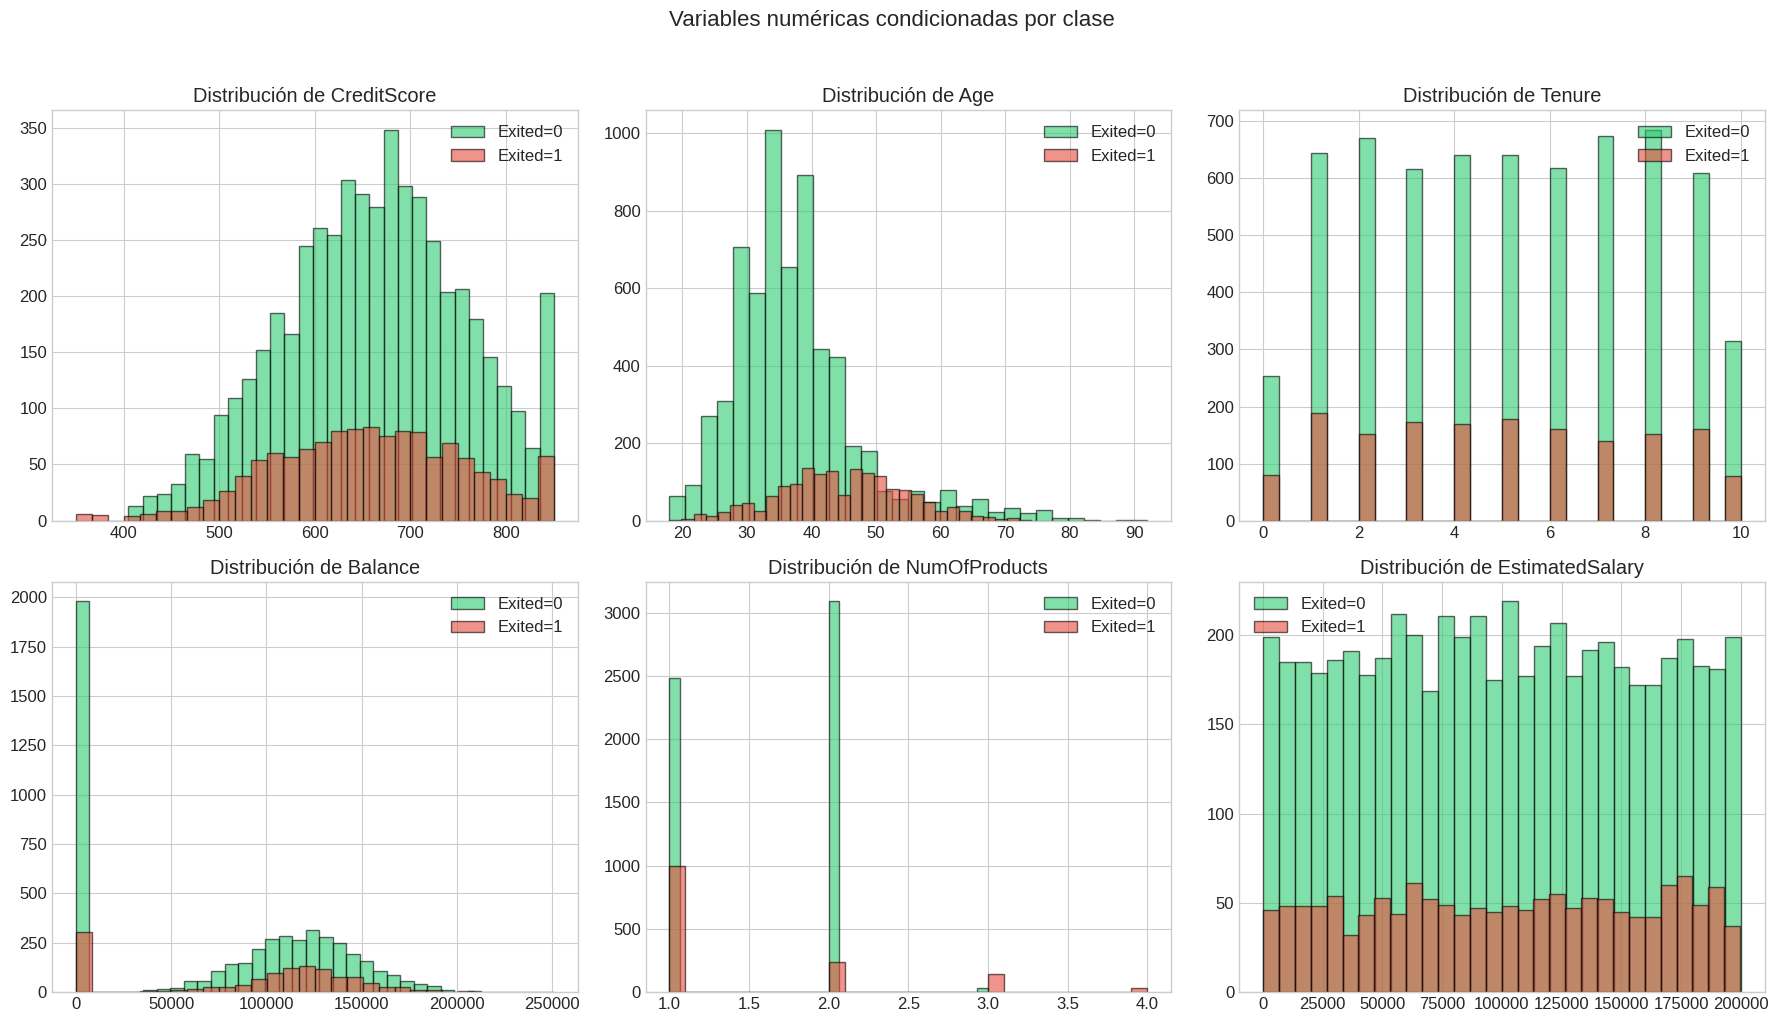

In [7]:
num_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for i, col in enumerate(num_cols):
    ax = axes.flatten()[i]
    for label, color in zip([0, 1], colors):
        ax.hist(train[train['Exited'] == label][col].dropna(), bins=30, alpha=0.6,
                color=color, label=f'Exited={label}', edgecolor='black')
    ax.set_title(f'Distribución de {col}')
    ax.legend()
plt.suptitle('Variables numéricas condicionadas por clase', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

Lo más claro es Age: los clientes que se van se concentran en el rango 40-55 años, mientras que los jóvenes tienden a quedarse. Balance también muestra algo de señal — los que tienen saldo positivo abandonan más.

### 3.4 Boxplots — Detección de outliers

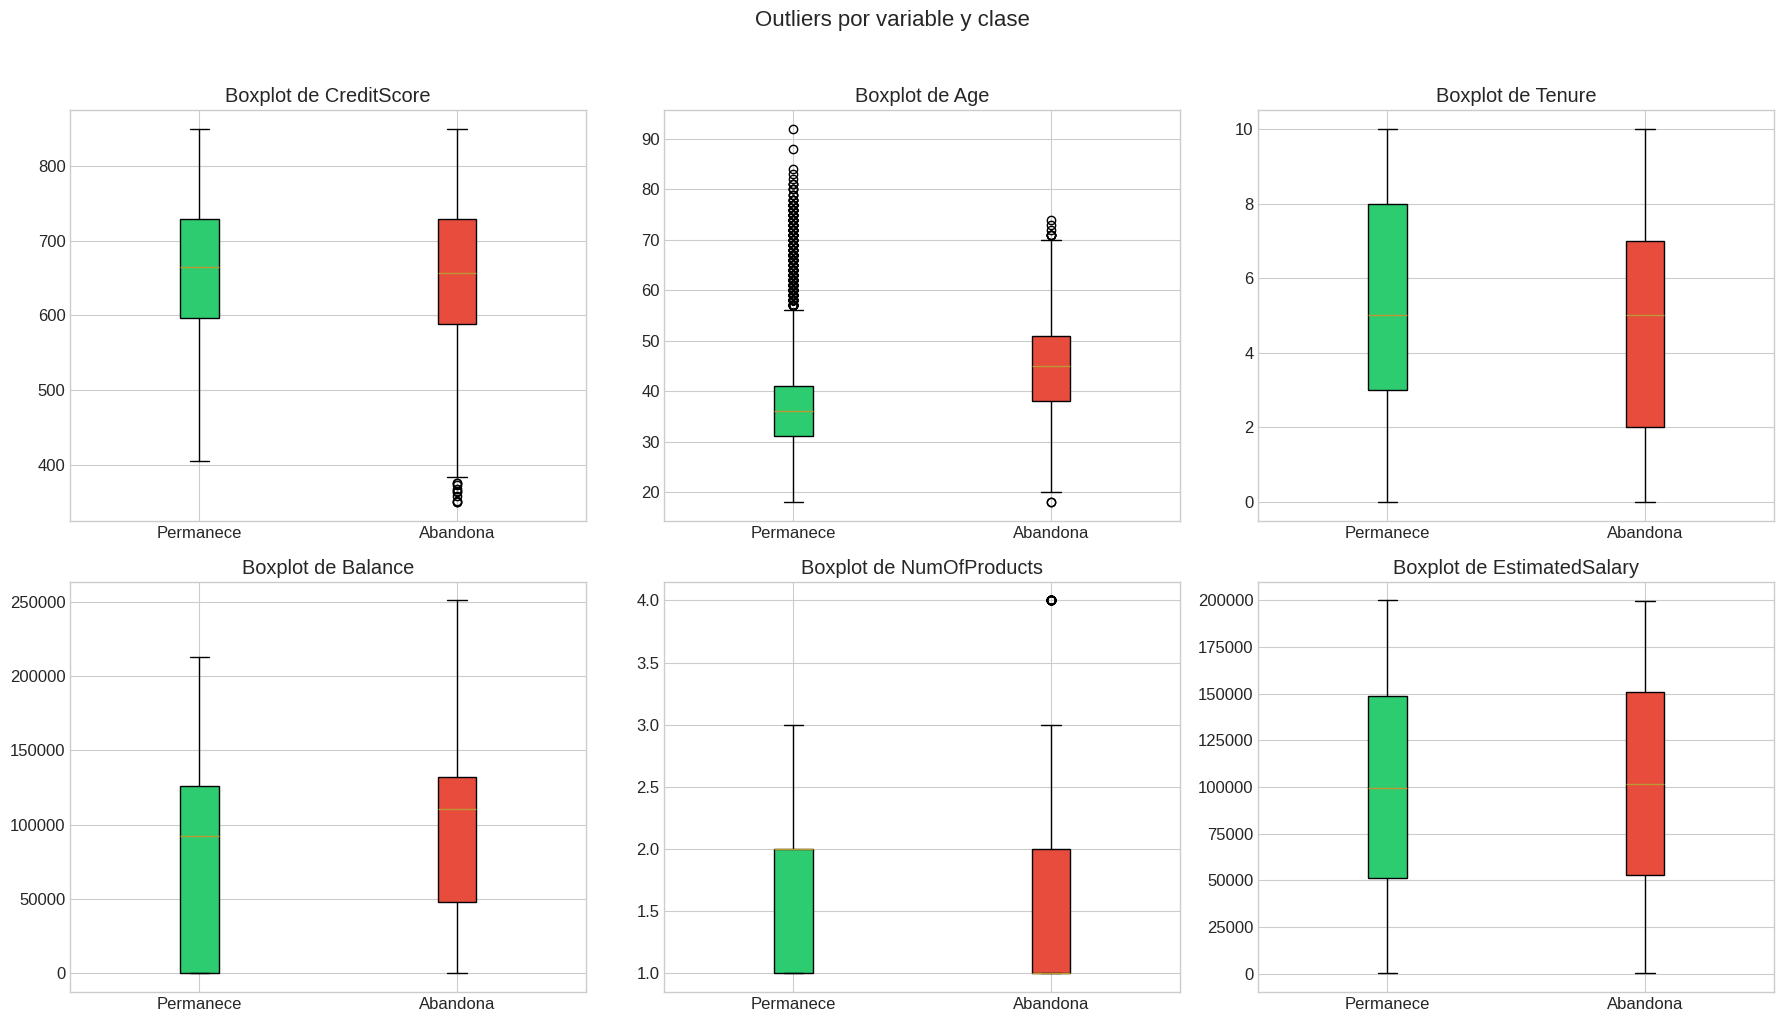

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for i, col in enumerate(num_cols):
    ax = axes.flatten()[i]
    data_list = [train[train['Exited'] == 0][col].dropna(), train[train['Exited'] == 1][col].dropna()]
    bp = ax.boxplot(data_list, labels=['Permanece', 'Abandona'], patch_artist=True)
    bp['boxes'][0].set_facecolor(colors[0])
    bp['boxes'][1].set_facecolor(colors[1])
    ax.set_title(f'Boxplot de {col}')
plt.suptitle('Outliers por variable y clase', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

Hay outliers en CreditScore (valores bajos) y Age (algunos clientes muy mayores). No los elimino porque son pocos casos y los modelos de árboles manejan bien los valores extremos.

### 3.5 Variables categóricas VS variable objetivo

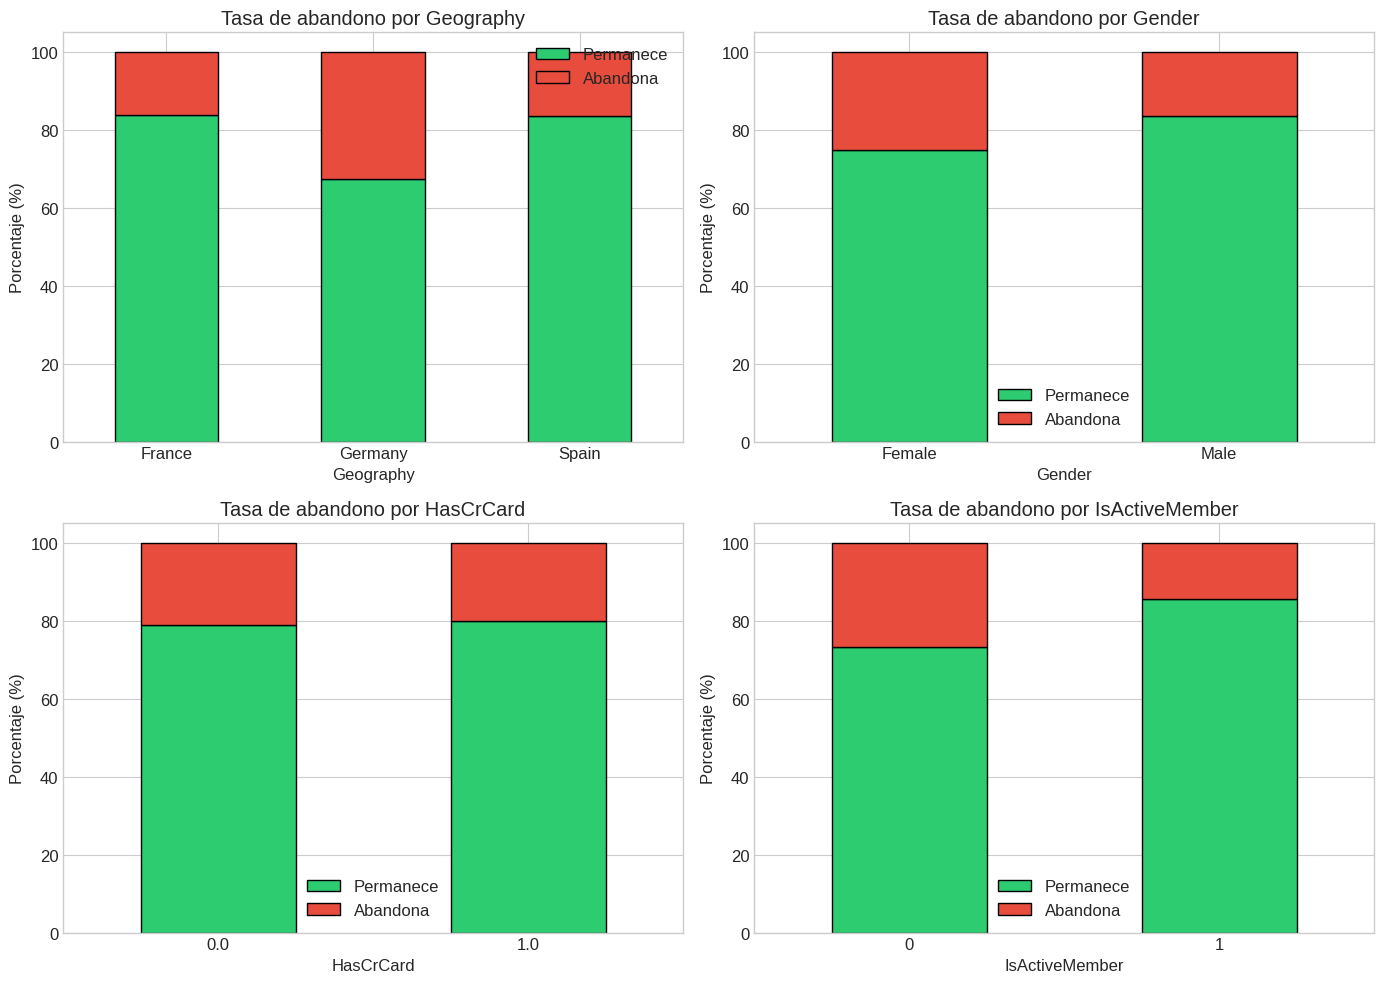


Tasa de abandono por Geography:
Exited        0     1
Geography            
France     83.7  16.3
Germany    67.4  32.6
Spain      83.6  16.4

Tasa de abandono por Gender:
Exited     0     1
Gender            
Female  74.9  25.1
Male    83.5  16.5


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for i, col in enumerate(['Geography', 'Gender', 'HasCrCard', 'IsActiveMember']):
    ax = axes.flatten()[i]
    ct = pd.crosstab(train[col], train['Exited'], normalize='index') * 100
    ct.plot(kind='bar', ax=ax, color=colors, edgecolor='black', stacked=True)
    ax.set_title(f'Tasa de abandono por {col}')
    ax.legend(['Permanece', 'Abandona'])
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.set_ylabel('Porcentaje (%)')
plt.tight_layout()
plt.show()

for col in ['Geography', 'Gender']:
    print(f'\nTasa de abandono por {col}:')
    print((pd.crosstab(train[col], train['Exited'], normalize='index') * 100).round(1))

Cosas interesantes:
- **Geography**: Alemania tiene una tasa de abandono del ~32.6%, el doble que Francia o España (~16%).
- **Gender**: las mujeres abandonan bastante más (~25% vs ~16.5%).
- **IsActiveMember**: los inactivos abandonan más (~26% vs ~14%), como era de esperar.
- **HasCrCard**: no hay diferencias, tener tarjeta de crédito no influye.

### 3.6 Matriz de correlación

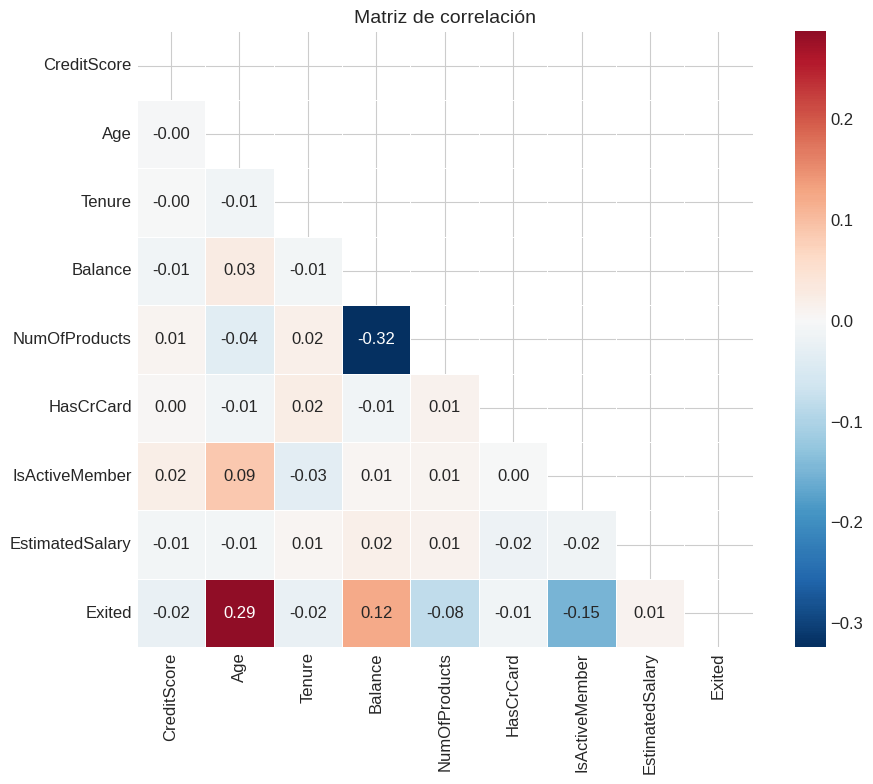

Correlación con Exited:
Age                0.287
IsActiveMember    -0.152
Balance            0.122
NumOfProducts     -0.082
CreditScore       -0.023
Tenure            -0.023
HasCrCard         -0.012
EstimatedSalary    0.012
Name: Exited, dtype: float64


In [10]:
numeric_train = train.select_dtypes(include=[np.number]).drop(columns=['CustomerId'])
corr_matrix = numeric_train.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title('Matriz de correlación', fontsize=14)
plt.tight_layout()
plt.show()

print('Correlación con Exited:')
print(corr_matrix['Exited'].drop('Exited').sort_values(key=abs, ascending=False).round(3))

Correlaciones con `Exited`:
- **Age** (0.287) — la más fuerte.
- **IsActiveMember** (-0.152) — ser activo protege contra el churn.
- **Balance** (0.122) — positiva, un poco contraintuitivo.
- **NumOfProducts** (-0.082) — débil.

No hay multicolinealidad entre predictoras, se pueden usar todas.

### 3.7 Análisis detallado de Age (variable más importante)

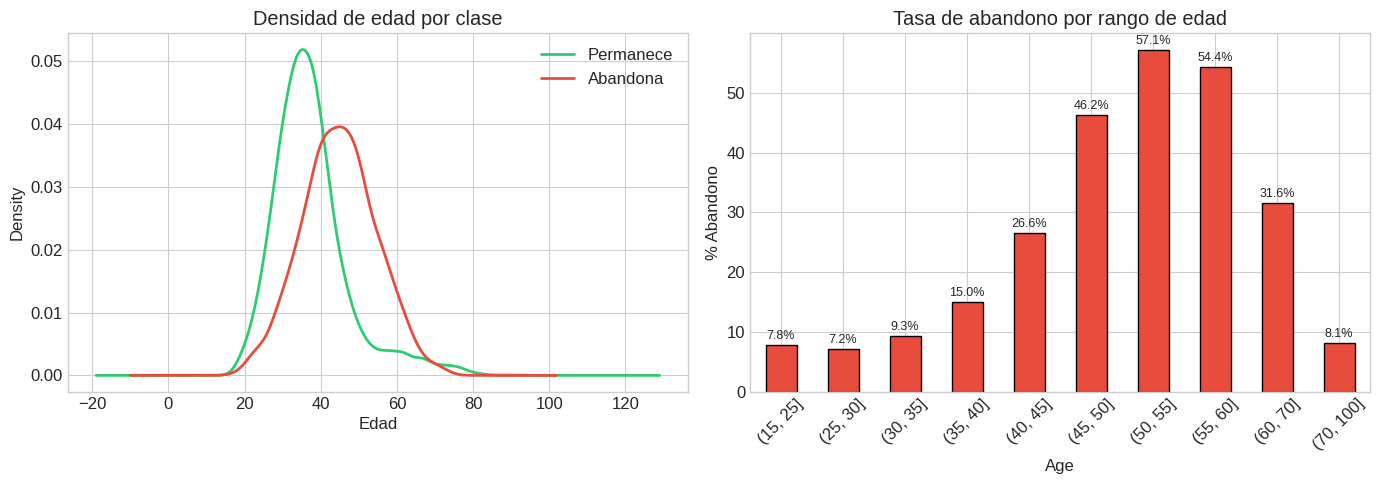

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución de edad por clase
train[train['Exited'] == 0]['Age'].dropna().plot.kde(ax=axes[0], label='Permanece', color=colors[0], linewidth=2)
train[train['Exited'] == 1]['Age'].dropna().plot.kde(ax=axes[0], label='Abandona', color=colors[1], linewidth=2)
axes[0].set_title('Densidad de edad por clase')
axes[0].set_xlabel('Edad')
axes[0].legend()

# Tasa de abandono por rango de edad
age_bins = pd.cut(train['Age'], bins=[15, 25, 30, 35, 40, 45, 50, 55, 60, 70, 100])
churn_by_age = train.groupby(age_bins, observed=False)['Exited'].mean() * 100
churn_by_age.plot(kind='bar', ax=axes[1], color='#e74c3c', edgecolor='black')
axes[1].set_title('Tasa de abandono por rango de edad')
axes[1].set_ylabel('% Abandono')
axes[1].set_xticklabels([str(x) for x in churn_by_age.index], rotation=45)
for i, v in enumerate(churn_by_age.values):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

La edad es claramente la variable más importante. La tasa de abandono es baja por debajo de 35 años y se dispara a partir de los 45-50, superando el 40% en algunos tramos.

### 3.8 Análisis de interacciones

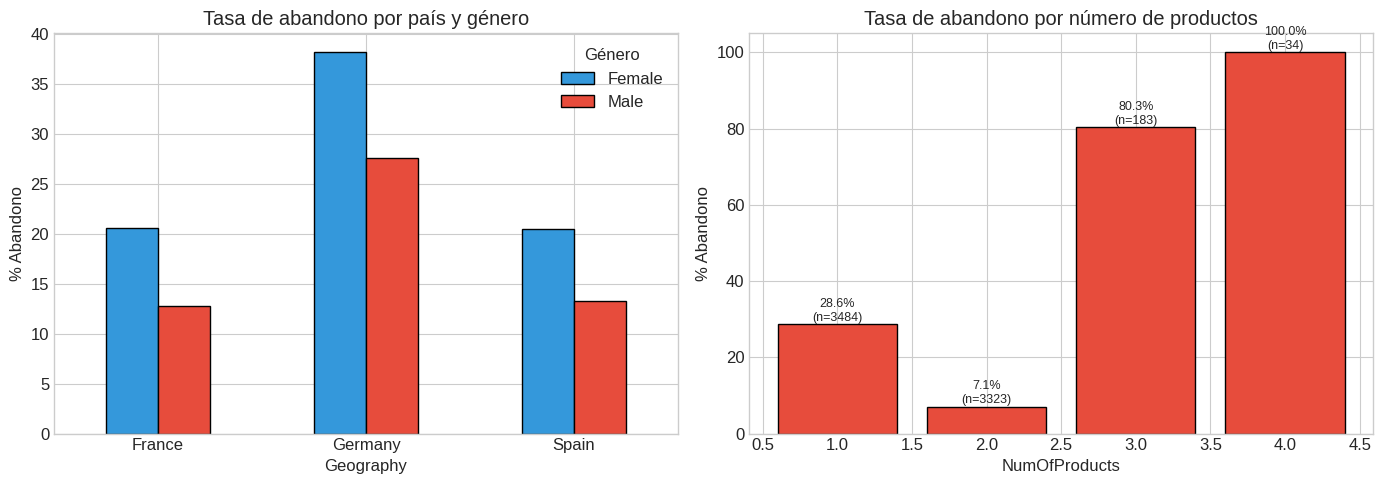

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ct = pd.crosstab([train['Geography'], train['Gender']], train['Exited'], normalize='index') * 100
ct[1].unstack().plot(kind='bar', ax=axes[0], color=['#3498db', '#e74c3c'], edgecolor='black')
axes[0].set_title('Tasa de abandono por país y género')
axes[0].set_ylabel('% Abandono')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend(title='Género')

# Abandono por NumOfProducts
churn_by_products = train.groupby('NumOfProducts')['Exited'].agg(['mean', 'count'])
churn_by_products['mean'] = churn_by_products['mean'] * 100
ax2 = axes[1]
bars = ax2.bar(churn_by_products.index, churn_by_products['mean'], color='#e74c3c', edgecolor='black')
ax2.set_title('Tasa de abandono por número de productos')
ax2.set_xlabel('NumOfProducts')
ax2.set_ylabel('% Abandono')
for bar, (idx, row) in zip(bars, churn_by_products.iterrows()):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{row["mean"]:.1f}%\n(n={int(row["count"])})', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

Las mujeres en Alemania son el grupo con mayor tasa de abandono en el cruce Geography × Gender. En cambio, el pico de churn en clientes con 3 o 4 productos hay que leerlo con cuidado: la tasa es muy alta, pero el número de casos es pequeño, así que lo tomé como una pista útil y no como una regla estable por sí sola.

## 4. Preparación de datos

Elimino `CustomerId` y `Surname` porque en las pruebas no aportan señal útil para predecir churn y solo añaden ruido al pipeline. A partir de aquí separo features y target.

### 4.1 Feature Engineering

Las variables nuevas salen directamente de lo que apareció en el EDA, no de una búsqueda masiva de combinaciones. Intenté resumir patrones que sí se veían en las gráficas y tablas: la no linealidad de la edad, el efecto de tener saldo, el caso particular de Alemania + mujer y la anomalía de clientes con muchos productos.

| Variable | Fórmula | Justificación |
|----------|---------|---------------|
| `AgeGroup` | Discretización de Age en rangos | La relación con el churn no es lineal; el salto fuerte aparece a partir de 45-50 años |
| `HasBalance` | Balance > 0 | En el EDA los clientes con saldo positivo abandonan más |
| `IsGermanyFemale` | Geography=='Germany' AND Gender=='Female' | Fue el cruce con peor comportamiento en tasa de abandono |
| `HighProducts` | NumOfProducts >= 3 | Recoge el pico de churn en clientes con muchos productos |
| `BalancePerProduct` | Balance / NumOfProducts | Resume cómo se reparte el saldo entre productos |

### 4.2 Selección de variables

Mantengo `HasCrCard` aunque su efecto aislado es flojo. En un problema con tan pocas variables prefiero dejar que el modelo descarte lo irrelevante antes que hacer poda agresiva sin ganancia clara.


Las variables derivadas conectan con varios conceptos de la asignatura:
- `AgeGroup` aplica una discretización no supervisada con bins definidos a partir del EDA.
- `IsGermanyFemale` introduce una interacción sencilla entre dos variables categóricas.

In [15]:
# Feature engineering: crear nuevas variables a partir del EDA
def add_features(df):
    df = df.copy()
    # Discretización de Age (el EDA muestra relación no lineal con Exited)
    df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 30, 40, 50, 60, 100], labels=[0, 1, 2, 3, 4]).astype(float)
    # Indicador de saldo > 0 (clientes con saldo abandonan más)
    df['HasBalance'] = (df['Balance'] > 0).astype(int)
    # Interacción: mujeres en Alemania (grupo con mayor tasa de abandono)
    df['IsGermanyFemale'] = ((df['Geography'] == 'Germany') & (df['Gender'] == 'Female')).astype(int)
    # Clientes con 3+ productos (tasas de abandono altísimas)
    df['HighProducts'] = (df['NumOfProducts'] >= 3).astype(int)
    # Saldo por producto
    df['BalancePerProduct'] = df['Balance'] / df['NumOfProducts'].replace(0, np.nan)
    return df

train = add_features(train)
test = add_features(test)

# Separar features y target
X_train = train.drop(columns=['Exited', 'CustomerId', 'Surname'])
y_train = train['Exited']
X_test = test.drop(columns=['CustomerId', 'Surname'])

print(f'Variables predictoras: {X_train.shape[1]}')
print(f'Instancias de entrenamiento: {X_train.shape[0]}')
print(f'Instancias de test: {X_test.shape[0]}')
print(f'\nVariables: {list(X_train.columns)}')

Variables predictoras: 15
Instancias de entrenamiento: 8000
Instancias de test: 2000

Variables: ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'AgeGroup', 'HasBalance', 'IsGermanyFemale', 'HighProducts', 'BalancePerProduct']


## 5. Pipeline de preprocesamiento

Todo el preprocesamiento va dentro de un pipeline de scikit-learn para no tener fugas de datos. El `ColumnTransformer` trata por separado:
- **Numéricas**: imputación por mediana → estandarización (StandardScaler)
- **Categóricas**: imputación por moda → one-hot encoding (`drop='first'`)

**Nota sobre StandardScaler**: los modelos basados en árboles (XGBoost, LightGBM, RF) son invariantes a transformaciones monotónicas, por lo que el escalado no les afecta. Sin embargo, se incluye en el pipeline porque la regresión logística sí se beneficia de datos estandarizados, y así el preprocesamiento es homogéneo para todos los modelos de la comparativa.

No uso SMOTE para el desbalanceo. Lo probé y dio peor recall en Kaggle. Mejor dejar que los modelos compensen internamente con `scale_pos_weight` o `class_weight='balanced'`.

In [16]:
numeric_features = [c for c in X_train.columns 
                    if c not in ['Geography', 'Gender'] 
                    and X_train[c].dtype != 'object']
categorical_features = ['Geography', 'Gender']

print(f'Variables numéricas ({len(numeric_features)}): {numeric_features}')
print(f'Variables categóricas ({len(categorical_features)}): {categorical_features}')

preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), numeric_features),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first'))
    ]), categorical_features)
], remainder='drop')

print('\nPipeline de preprocesamiento definido (sin SMOTE).')

Variables numéricas (13): ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'AgeGroup', 'HasBalance', 'IsGermanyFemale', 'HighProducts', 'BalancePerProduct']
Variables categóricas (2): ['Geography', 'Gender']

Pipeline de preprocesamiento definido (sin SMOTE).


## 5.1 Análisis de relevancia de variables (Feature Selection)

Antes de entrenar los modelos, analizo la relevancia de cada variable con dos enfoques complementarios:

1. **Método Filter (Ganancia de Información)**: calcula la información mutua entre cada variable y el target, sin depender de ningún modelo concreto. Es el enfoque visto como *evaluación filter univariada*.

2. **Método Embedded (Feature Importance de XGBoost)**: se obtiene tras entrenar el modelo final. Los árboles de decisión realizan internamente una selección de variables al elegir las mejores particiones.

Con solo 15 variables (10 originales + 5 derivadas) y 8.000 instancias, no estamos en un escenario de alta dimensionalidad donde la maldición de la dimensionalidad sea crítica. Aún así, el análisis permite identificar qué features aportan y cuáles son redundantes.

=== Ranking de variables por Ganancia de Información (Filter) ===
          Feature  InfoGain
              Age  0.071693
    NumOfProducts  0.065490
         AgeGroup  0.054679
     HighProducts  0.030399
   IsActiveMember  0.009726
  IsGermanyFemale  0.009681
BalancePerProduct  0.005257
  EstimatedSalary  0.005215
          Balance  0.003651
           Tenure  0.001634
        HasCrCard  0.000181
       HasBalance  0.000025
      CreditScore  0.000000


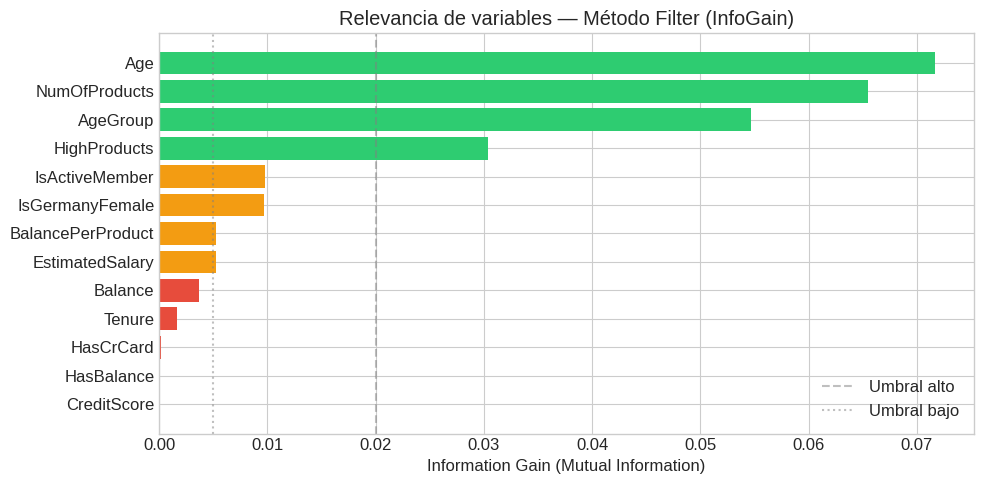


Variables con alta relevancia (IG > 0.02): ['Age', 'NumOfProducts', 'AgeGroup', 'HighProducts']
Variables con baja relevancia (IG < 0.005): ['Balance', 'Tenure', 'HasCrCard', 'HasBalance', 'CreditScore']

Nota: No elimino las variables de baja relevancia porque los modelos basados en árboles
pueden ignorarlas sin penalización. La selección es implícita (embedded) en el modelo.


In [17]:
from sklearn.feature_selection import mutual_info_classif

# --- Método Filter: Ganancia de Información (Information Gain) ---
# Solo variables numéricas (las categóricas se codificarán en el pipeline)
X_num = X_train.select_dtypes(include=[np.number])
mi_scores = mutual_info_classif(X_num.fillna(0), y_train, random_state=42)
mi_df = pd.DataFrame({'Feature': X_num.columns, 'InfoGain': mi_scores})
mi_df = mi_df.sort_values('InfoGain', ascending=False).reset_index(drop=True)

print('=== Ranking de variables por Ganancia de Información (Filter) ===')
print(mi_df.to_string(index=False))

# Visualización
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#2ecc71' if v > 0.02 else '#e74c3c' if v < 0.005 else '#f39c12' for v in mi_df['InfoGain']]
ax.barh(mi_df['Feature'][::-1], mi_df['InfoGain'][::-1], color=colors[::-1])
ax.set_xlabel('Information Gain (Mutual Information)')
ax.set_title('Relevancia de variables — Método Filter (InfoGain)')
ax.axvline(x=0.02, color='gray', linestyle='--', alpha=0.5, label='Umbral alto')
ax.axvline(x=0.005, color='gray', linestyle=':', alpha=0.5, label='Umbral bajo')
ax.legend()
plt.tight_layout()
plt.savefig('infogain_ranking.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nVariables con alta relevancia (IG > 0.02): {list(mi_df[mi_df["InfoGain"] > 0.02]["Feature"])}')
print(f'Variables con baja relevancia (IG < 0.005): {list(mi_df[mi_df["InfoGain"] < 0.005]["Feature"])}')
print('\nNota: No elimino las variables de baja relevancia porque los modelos basados en árboles')
print('pueden ignorarlas sin penalización. La selección es implícita (embedded) en el modelo.')

## 6. Comparación de modelos base

Comparo 7 modelos con validación cruzada estratificada (5 folds), midiendo recall, precisión, F1 y AUC. Los modelos van desde regresión logística hasta gradient boosting (XGBoost, LightGBM). Todos compensan el desbalanceo de clases de alguna forma.

In [18]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {'recall': 'recall', 'precision': 'precision', 'f1': 'f1', 'roc_auc': 'roc_auc'}

models = {
    'XGBoost (pw=3)': XGBClassifier(
        scale_pos_weight=3, n_estimators=300, max_depth=5,
        learning_rate=0.05, random_state=RANDOM_STATE,
        eval_metric='logloss', verbosity=0, n_jobs=-1
    ),
    'XGBoost (pw=2)': XGBClassifier(
        scale_pos_weight=2, n_estimators=300, max_depth=5,
        learning_rate=0.05, random_state=RANDOM_STATE,
        eval_metric='logloss', verbosity=0, n_jobs=-1
    ),
    'LightGBM (unbal)': LGBMClassifier(
        is_unbalance=True, n_estimators=300, max_depth=5,
        learning_rate=0.05, random_state=RANDOM_STATE,
        n_jobs=-1, verbose=-1
    ),
    'LightGBM (pw=3)': LGBMClassifier(
        scale_pos_weight=3, n_estimators=300, max_depth=5,
        learning_rate=0.05, random_state=RANDOM_STATE,
        n_jobs=-1, verbose=-1
    ),
    'GBM': GradientBoostingClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.05,
        random_state=RANDOM_STATE
    ),
    'Random Forest': RandomForestClassifier(
        class_weight='balanced', n_estimators=300, max_depth=10,
        random_state=RANDOM_STATE, n_jobs=-1
    ),
    'LogReg': LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE
    ),
}

results = {}
print(f"{'Modelo':<25} {'Recall':>12} {'Precision':>10} {'F1':>8} {'AUC':>8}")
print('-' * 70)

for name, model in models.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('classifier', model)])
    scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    r = {k: scores[f'test_{k}'].mean() for k in scoring}
    r['recall_std'] = scores['test_recall'].std()
    results[name] = r
    print(f"{name:<25} {r['recall']:.4f}±{r['recall_std']:.3f} {r['precision']:>8.4f} {r['f1']:>8.4f} {r['roc_auc']:>8.4f}")

Modelo                          Recall  Precision       F1      AUC
----------------------------------------------------------------------
XGBoost (pw=3)            0.6405±0.024   0.5469   0.5897   0.8457
XGBoost (pw=2)            0.5730±0.026   0.6112   0.5909   0.8463
LightGBM (unbal)          0.6914±0.025   0.5065   0.5845   0.8448
LightGBM (pw=3)           0.6534±0.023   0.5526   0.5985   0.8448
GBM                       0.4613±0.026   0.7141   0.5601   0.8432
Random Forest             0.6141±0.023   0.5767   0.5946   0.8459
LogReg                    0.7454±0.021   0.4359   0.5500   0.8258


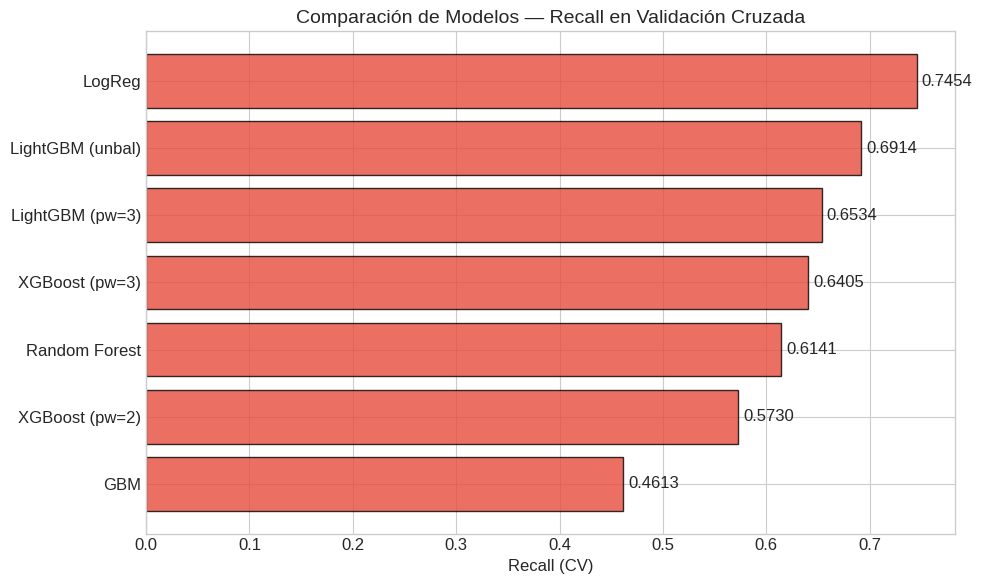

In [19]:
# Visualización de la comparativa
results_df = pd.DataFrame(results).T.sort_values('recall', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
y_pos = range(len(results_df))
bars = ax.barh(y_pos, results_df['recall'], color='#e74c3c', edgecolor='black', alpha=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels(results_df.index)
ax.set_xlabel('Recall (CV)')
ax.set_title('Comparación de Modelos — Recall en Validación Cruzada', fontsize=14)
for i, (idx, row) in enumerate(results_df.iterrows()):
    ax.text(row['recall'] + 0.005, i, f"{row['recall']:.4f}", va='center')
plt.tight_layout()
plt.show()

Los AUC quedan todos en torno a 0.84, así que la diferencia real no está en separar mejor o peor las clases, sino en cómo se intercambian recall y precisión. La regresión logística recupera muchos positivos, pero deja demasiados falsos positivos para lo que luego terminé viendo en Kaggle.

Por eso concentré el tuning en **XGBoost** y **LightGBM**: no eran los líderes absolutos en recall bruto, pero sí los modelos más razonables para trabajar el desbalanceo y buscar un equilibrio que luego no se hundiera al pasar al conjunto oculto de la competición.

## 7. Optimización de hiperparámetros

Uso `RandomizedSearchCV` para buscar los mejores hiperparámetros de XGBoost y LightGBM, optimizando recall. La evaluación interna es validación cruzada estratificada.

### 7.1 XGBoost

In [20]:
xgb_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss', verbosity=0, n_jobs=-1))
])
xgb_params = {
    'classifier__n_estimators': [200, 300, 500, 700],
    'classifier__max_depth': [3, 4, 5, 6, 7],
    'classifier__learning_rate': [0.01, 0.03, 0.05, 0.1],
    'classifier__min_child_weight': [1, 3, 5, 7],
    'classifier__scale_pos_weight': [2, 3, 4],
    'classifier__subsample': [0.7, 0.8, 0.9],
    'classifier__colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'classifier__reg_alpha': [0, 0.01, 0.1],
    'classifier__reg_lambda': [1, 2, 5],
    'classifier__gamma': [0, 0.1, 0.5],
}

xgb_search = RandomizedSearchCV(
    xgb_pipe, xgb_params, n_iter=80, cv=cv, scoring='recall',
    random_state=RANDOM_STATE, n_jobs=-1, verbose=0
)
print('Optimizando XGBoost (80 iteraciones)...')
xgb_search.fit(X_train, y_train)
print(f'Mejor recall CV: {xgb_search.best_score_:.4f}')
print(f'Parámetros: {xgb_search.best_params_}')

Optimizando XGBoost (80 iteraciones)...
Mejor recall CV: 0.7393
Parámetros: {'classifier__subsample': 0.8, 'classifier__scale_pos_weight': 4, 'classifier__reg_lambda': 2, 'classifier__reg_alpha': 0, 'classifier__n_estimators': 300, 'classifier__min_child_weight': 3, 'classifier__max_depth': 3, 'classifier__learning_rate': 0.03, 'classifier__gamma': 0, 'classifier__colsample_bytree': 1.0}


### 7.2 LightGBM

In [22]:
lgbm_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LGBMClassifier(random_state=RANDOM_STATE, n_jobs=1, verbose=-1)) 
])
lgbm_params = {
    'classifier__n_estimators': [200, 300, 500],
    'classifier__max_depth': [3, 5, 7, -1],
    'classifier__learning_rate': [0.01, 0.05, 0.1],
    'classifier__num_leaves': [15, 20, 31],
    'classifier__min_child_samples': [10, 20, 30],
    'classifier__scale_pos_weight': [2, 3, 4],
    'classifier__subsample': [0.8, 0.9, 1.0],
    'classifier__colsample_bytree': [0.8, 0.9, 1.0],
    'classifier__reg_alpha': [0, 0.01, 0.1],
    'classifier__reg_lambda': [0, 1, 5],
}
lgbm_search = RandomizedSearchCV(
    lgbm_pipe, 
    lgbm_params, 
    n_iter=60, 
    cv=cv, 
    scoring='recall',
    random_state=RANDOM_STATE, 
    n_jobs=-1,
    verbose=1
)

print('Optimizando LightGBM (60 iteraciones)...')
lgbm_search.fit(X_train, y_train)
print(f'Mejor recall CV: {lgbm_search.best_score_:.4f}')
print(f'Parámetros: {lgbm_search.best_params_}')

Optimizando LightGBM (60 iteraciones)...
Fitting 5 folds for each of 60 candidates, totalling 300 fits


Mejor recall CV: 0.7423
Parámetros: {'classifier__subsample': 0.9, 'classifier__scale_pos_weight': 4, 'classifier__reg_lambda': 5, 'classifier__reg_alpha': 0.01, 'classifier__num_leaves': 15, 'classifier__n_estimators': 200, 'classifier__min_child_samples': 20, 'classifier__max_depth': 3, 'classifier__learning_rate': 0.05, 'classifier__colsample_bytree': 0.9}


### 7.3 Resumen de optimización

In [23]:
tuned_results = {
    'XGBoost': xgb_search.best_score_,
    'LightGBM': lgbm_search.best_score_,
}

print(f"{'Modelo':<20} {'Mejor Recall CV':>15}")
print('-' * 40)
for name, score in sorted(tuned_results.items(), key=lambda x: x[1], reverse=True):
    print(f'{name:<20} {score:>15.4f}')

Modelo               Mejor Recall CV
----------------------------------------
LightGBM                      0.7423
XGBoost                       0.7393


Con el tuning se mejora el recall respecto a los modelos base. El parámetro `scale_pos_weight` es clave para compensar el desbalanceo.

### 7.4 Feature Importance (Método Embedded)

Los modelos de gradient boosting realizan selección de variables implícita al construir los árboles. Visualizo la importancia de cada feature según el XGBoost optimizado (basada en *gain*: cuánto reduce cada variable la función de pérdida).

=== Feature Importance (XGBoost, método Embedded) ===
          Feature  Importance
       HasBalance    0.190246
              Age    0.163861
    NumOfProducts    0.126959
   IsActiveMember    0.109675
Geography_Germany    0.092982
  IsGermanyFemale    0.068632
      Gender_Male    0.060160
BalancePerProduct    0.051255
          Balance    0.041356
           Tenure    0.020981
  Geography_Spain    0.018929
      CreditScore    0.018482
  EstimatedSalary    0.018365
        HasCrCard    0.018119
     HighProducts    0.000000
         AgeGroup    0.000000


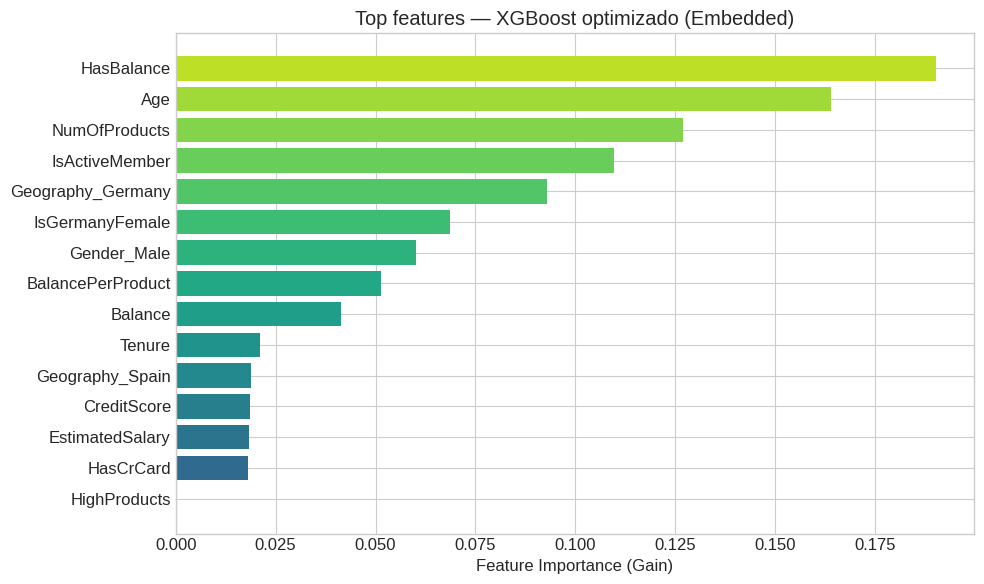


--- Comparación Filter vs Embedded ---
Top 5 por InfoGain:  ['Age', 'NumOfProducts', 'AgeGroup', 'HighProducts', 'IsActiveMember']
Top 5 por XGBoost:   ['HasBalance', 'Age', 'NumOfProducts', 'IsActiveMember', 'Geography_Germany']


In [25]:
best_xgb_pipe = xgb_search.best_estimator_
xgb_model = best_xgb_pipe.named_steps['classifier']
feature_names_out = best_xgb_pipe.named_steps['preprocessor'].get_feature_names_out()
# Limpiar nombres
feature_names_out = [n.replace('num__', '').replace('cat__', '') for n in feature_names_out]

importances = xgb_model.feature_importances_
fi_df = pd.DataFrame({'Feature': feature_names_out, 'Importance': importances})
fi_df = fi_df.sort_values('Importance', ascending=False).reset_index(drop=True)

print('=== Feature Importance (XGBoost, método Embedded) ===')
print(fi_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
top_n = min(15, len(fi_df))
colors = plt.cm.viridis(np.linspace(0.3, 0.9, top_n))
ax.barh(fi_df['Feature'][:top_n][::-1], fi_df['Importance'][:top_n][::-1], color=colors)
ax.set_xlabel('Feature Importance (Gain)')
ax.set_title('Top features — XGBoost optimizado (Embedded)')
plt.tight_layout()
plt.savefig('feature_importance_xgb.png', dpi=150, bbox_inches='tight')
plt.show()

# Comparación con InfoGain
print('\n--- Comparación Filter vs Embedded ---')
print(f'Top 5 por InfoGain:  {list(mi_df.head(5)["Feature"])}')
print(f'Top 5 por XGBoost:   {list(fi_df.head(5)["Feature"])}')

## 8. Ajuste del umbral de decisión

Los clasificadores devuelven probabilidades, y el umbral por defecto (0.5) asume que los dos tipos de error pesan lo mismo. Como nos interesa maximizar el recall (no perder clientes que se van), tiene sentido probar umbrales más bajos.

Para elegir el umbral uso probabilidades Out-of-Fold (OOF): las predicciones de la validación cruzada sobre datos que no ha visto en cada fold. Así el ajuste del umbral no sobreajusta a los datos de entrenamiento.

In [26]:
# Obtener probabilidades OOF para cada modelo optimizado
print('Calculando probabilidades Out-of-Fold...')

oof_models = {
    'XGBoost': xgb_search.best_estimator_,
    'LightGBM': lgbm_search.best_estimator_,
}

oof_probas = {}
for name, pipe_model in oof_models.items():
    proba = cross_val_predict(pipe_model, X_train, y_train, cv=cv, method='predict_proba')[:, 1]
    oof_probas[name] = proba
    print(f'  {name}: OOF calculado')

# Ensemble simple: media de probabilidades XGBoost + LightGBM
oof_probas['Ensemble_xgb_lgbm'] = np.mean(
    [oof_probas['XGBoost'], oof_probas['LightGBM']], axis=0)

print('\nProbabilidades OOF calculadas.')

Calculando probabilidades Out-of-Fold...
  XGBoost: OOF calculado
  LightGBM: OOF calculado

Probabilidades OOF calculadas.


In [27]:
# Busqueda del mejor umbral - Maximizar recall con precision >= 30%
print(f"{'Modelo':<25} {'Umbral':>8} {'Recall':>8} {'Precision':>10} {'F1':>8}")
print('-' * 65)

threshold_data = {}
for name, proba in oof_probas.items():
    best_t, best_r, best_p, best_f = 0.5, 0, 0, 0
    for t in np.arange(0.20, 0.60, 0.005):
        yp = (proba >= t).astype(int)
        rec = recall_score(y_train, yp)
        prec = precision_score(y_train, yp)
        f1 = f1_score(y_train, yp)
        if rec > best_r and prec >= 0.30:
            best_r, best_t, best_p, best_f = rec, t, prec, f1
    threshold_data[name] = {'threshold': best_t, 'recall': best_r, 'precision': best_p, 'f1': best_f}
    print(f"{name:<25} {best_t:>8.3f} {best_r:>8.4f} {best_p:>10.4f} {best_f:>8.4f}")

Modelo                      Umbral   Recall  Precision       F1
-----------------------------------------------------------------
XGBoost                      0.230   0.9460     0.3022   0.4580
LightGBM                     0.235   0.9466     0.3015   0.4573
Ensemble_xgb_lgbm            0.235   0.9472     0.3032   0.4594


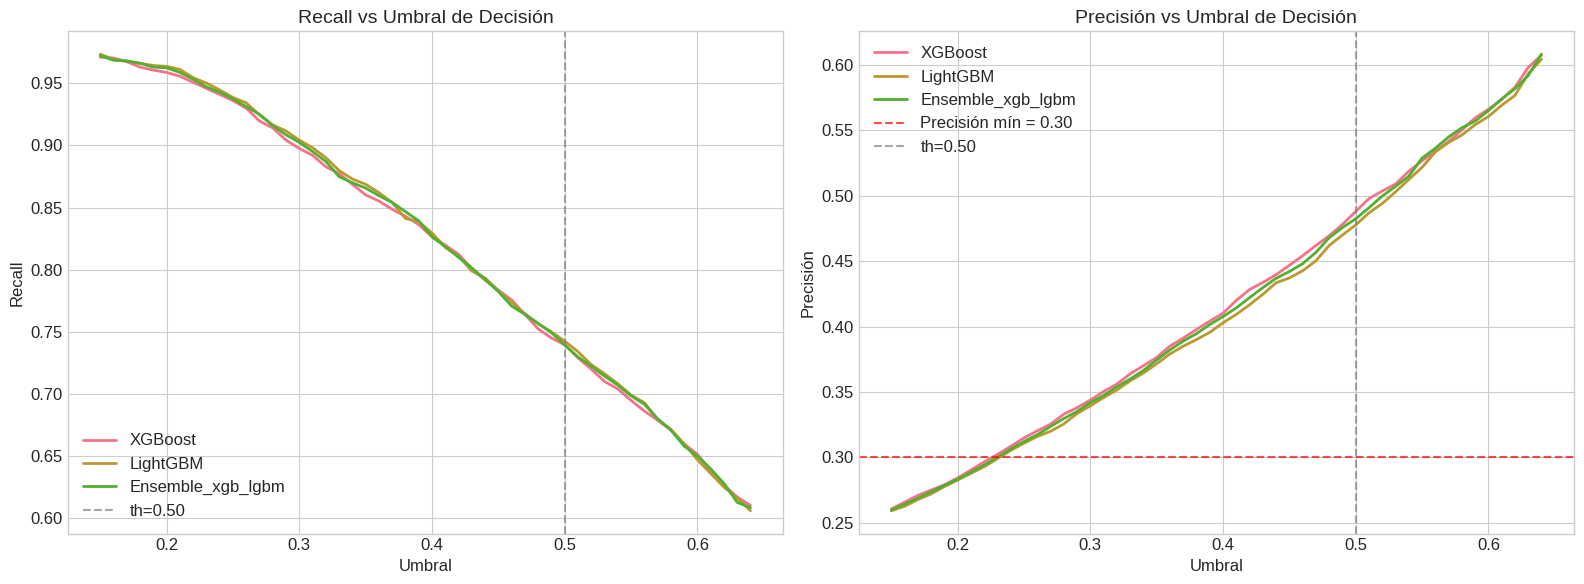

In [28]:
# Visualización: Recall vs Umbral para los principales modelos
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for name in ['XGBoost', 'LightGBM', 'Ensemble_xgb_lgbm']:
    proba = oof_probas[name]
    thresholds = np.arange(0.15, 0.65, 0.01)
    recalls = [recall_score(y_train, (proba >= t).astype(int)) for t in thresholds]
    precisions = [precision_score(y_train, (proba >= t).astype(int)) for t in thresholds]
    
    axes[0].plot(thresholds, recalls, label=name, linewidth=2)
    axes[1].plot(thresholds, precisions, label=name, linewidth=2)

axes[0].axvline(x=0.50, color='gray', linestyle='--', alpha=0.7, label='th=0.50')
axes[0].set_title('Recall vs Umbral de Decisión', fontsize=14)
axes[0].set_xlabel('Umbral')
axes[0].set_ylabel('Recall')
axes[0].legend()

axes[1].axhline(y=0.30, color='red', linestyle='--', alpha=0.7, label='Precisión mín = 0.30')
axes[1].axvline(x=0.50, color='gray', linestyle='--', alpha=0.7, label='th=0.50')
axes[1].set_title('Precisión vs Umbral de Decisión', fontsize=14)
axes[1].set_xlabel('Umbral')
axes[1].set_ylabel('Precisión')
axes[1].legend()

plt.tight_layout()
plt.show()

El análisis OOF sugiere umbrales en torno a 0.25, pero al subir las submissions a Kaggle el **umbral 0.50 dio mejor resultado** en todos los casos. Bajar el umbral mejora el recall en CV pero lo empeora en Kaggle — el ajuste agresivo sobreajusta al train.

Genero submissions con varios umbrales (0.30 a 0.50) para comparar en Kaggle directamente.

## 9. Generación de predicciones

Entreno los modelos con todos los datos de entrenamiento y genero archivos csv con distintas combinaciones de modelo y umbral.

In [29]:
# Entrenar modelos finales con todos los datos
print('Entrenando modelos finales con todos los datos...')
for name, pipe_model in oof_models.items():
    pipe_model.fit(X_train, y_train)
    print(f'  {name} entrenado')

# Obtener probabilidades en test
test_probas = {}
for name, pipe_model in oof_models.items():
    test_probas[name] = pipe_model.predict_proba(X_test)[:, 1]

print('\nProbabilidades calculadas para test.')

Entrenando modelos finales con todos los datos...
  XGBoost entrenado
  LightGBM entrenado

Probabilidades calculadas para test.


In [ ]:
# Generar submissions para XGBoost y LightGBM con distintos umbrales
print('Generando archivos de submission...')
print(f"{'Archivo':<45} {'Abandonos':>10} {'%':>6}")
print('-' * 65)

submission_dir = 'submissions'
os.makedirs(submission_dir, exist_ok=True)

submission_count = 0
for model_name in ['XGBoost', 'LightGBM']:
    proba = test_probas[model_name]
    for thresh in [0.30, 0.35, 0.40, 0.45, 0.50]:
        yp = (proba >= thresh).astype(int)
        n_churn = yp.sum()
        pct = n_churn / len(yp) * 100
        short_name = model_name.lower().replace(' ', '')
        filename = f'submission_{short_name}_th{int(thresh*100)}.csv'
        output_path = os.path.join(submission_dir, filename)
        sub = pd.DataFrame({'CustomerId': test_ids, 'Exited': yp})
        sub.to_csv(output_path, index=False)
        submission_count += 1
        print(f'  {output_path:<43} {n_churn:>10} {pct:>5.1f}%')

print(f'\nTotal: {submission_count} archivos de submission generados.')

Generando archivos de submission...
Archivo                                        Abandonos      %
-----------------------------------------------------------------
  submission_xgboost_th30.csv                       1063  53.1%
  submission_xgboost_th35.csv                        915  45.8%
  submission_xgboost_th40.csv                        807  40.4%
  submission_xgboost_th45.csv                        704  35.2%
  submission_xgboost_th50.csv                        618  30.9%
  submission_lightgbm_th30.csv                      1083  54.1%
  submission_lightgbm_th35.csv                       949  47.4%
  submission_lightgbm_th40.csv                       822  41.1%
  submission_lightgbm_th45.csv                       713  35.6%
  submission_lightgbm_th50.csv                       631  31.6%

Total: 10 archivos de submission generados.


## Resultados en Kaggle

| # | Submission | Private Score | Public Score |
|:-:|-----------|:------------:|:------------:|
| 1 | `submission_xgboost_th50.csv` | **0.58367** | 0.59602 |
| 2 | `submission_lightgbm_th50.csv` | 0.57923 | 0.60784 |
| 3 | `submission_lightgbm_th45.csv` | 0.57541 | 0.58006 |
| 4 | `submission_xgboost_th45.csv` | 0.56815 | 0.58282 |
| 5 | `submission_xgboost_th40.csv` | 0.55542 | 0.53781 |
| 6 | `submission_lightgbm_th40.csv` | 0.55491 | 0.53296 |
| 7 | `submission_xgboost_th35.csv` | 0.53533 | 0.50000 |
| 8 | `submission_lightgbm_th35.csv` | 0.52763 | 0.50377 |
| 9 | `submission_xgboost_th30.csv` | 0.50241 | 0.48275 |
| 10 | `submission_lightgbm_th30.csv` | 0.49857 | 0.48291 |

**Modelo final: `submission_xgboost_th50.csv` — XGBoost con umbral 0.50, Recall = 0.58367.**
